In [1]:
import os
import polars as pl
import altair as alt

pl.Config(tbl_rows=100)
pl.Config(fmt_str_lengths=150)
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [2]:
df = pl.read_parquet(
    "data/segments.parquet"
).sort(
    ["id", "date"]
).with_columns(
    days_diff = pl.col("date").diff().dt.total_days().over("id"),
    effort_diff = pl.col("effort_count").diff().over("id")
).with_columns(
    avg_daily_efforts = pl.col("effort_diff") / pl.col("days_diff")
).with_columns(
    pl.when(pl.col("city").str.contains("Praha") | pl.col("city").str.contains("Prague")).then(pl.lit('Praha')).when(pl.col('city').str.contains('Brno')).then(pl.lit('Brno')).otherwise(pl.col('city')).alias('city'),
    pl.when(pl.col("effort_diff") < 0).then(pl.lit(0)).otherwise(pl.col("effort_diff")).alias("effort_diff")
)

In [3]:
df.sample(1)

id,name,activity_type,distance,average_grade,elevation_high,elevation_low,total_elevation_gain,start_latlng,end_latlng,country,state,city,effort_count,athlete_count,date,start_to_finish_distance,days_diff,effort_diff,avg_daily_efforts
i64,str,str,f64,f64,f64,f64,f64,list[f64],list[f64],str,str,str,i64,i64,"datetime[μs, CET]",f64,i64,i64,f64
13215965,"""Pod Vilemínkou - Kralický Sněžník (žlutá)""","""Hike""",4939.8,11.4,1424.6,860.6,595.0,"[50.185342, 16.841476]","[50.207429, 16.847453]","""Poland""","""Województwo dolnośląskie""",null,980,925,2025-08-25 23:21:51 CEST,2.492542,0,0,NaN


In [4]:
df.filter(pl.col('activity_type') == 'Run').filter(pl.col('city') == "Praha").group_by('name').agg(pl.col('effort_diff').sum()).sort(by='effort_diff',descending=True)

name,effort_diff
str,i64
"""Šlechtovka - finální rovinka""",46580
"""Stadion Na Děkance""",42772
"""Pražačka 320""",38292
"""Štvanická lávka (do Karlína)""",21285
"""TJ Sokol okruh""",19351
"""Most Legií (směr Kampa)""",17128
"""Vítkov up sprint""",16426
"""Strahovská dráha""",15958
"""Karlův most ONLY""",10409


In [5]:
sledujeme = [
    "Šlechtovka - finální rovinka","Štvanická lávka (do Karlína)","Most Legií (směr Kampa)","Vítkov up sprint","Hvězda flat","Šárka Valley (short)","Stodůlecký - Nepomucký rybník"
]

In [6]:
pocasi = pl.read_parquet(os.path.join('data','pocasi_klementinum.parquet'))
pocasi = pocasi.filter(pl.col('DT').dt.year() >= 2025).pivot('co',values='VALUE').group_by('DT').agg(pl.col(['srazky','slunecni_svit','teplota','vlhkost']).max()).sort(by='DT')
pocasi.sample(10).sort(by='DT')

DT,srazky,slunecni_svit,teplota,vlhkost
date,f64,f64,f64,f64
2025-04-02,0.0,5.4,16.4,68.0
2025-04-27,0.0,12.2,16.5,60.0
2025-06-14,0.0,13.6,26.6,58.0
2025-06-21,0.0,13.8,25.3,55.0
2025-06-23,4.0,4.4,29.6,54.0
2025-06-25,0.0,7.0,29.4,50.0
2025-08-30,0.0,5.3,24.7,86.0
2025-09-05,38.2,0.8,21.2,90.0
2025-09-28,0.0,9.1,19.4,87.0


In [7]:
pracovni_nepracovni = pl.read_parquet("../kniha-rok/data/pracovni-polopracovni-nepracovni-dny.parquet")
pracovni_nepracovni

datum,den,vikend,pracovni-nepracovni,tyden
date,i32,bool,str,str
2024-02-18,7,true,"""nepracovni""",null
2024-02-19,1,false,"""pracovni""","""normalni"""
2024-02-20,2,false,"""pracovni""","""normalni"""
2024-02-21,3,false,"""pracovni""","""normalni"""
2024-02-22,4,false,"""pracovni""","""normalni"""
2024-02-23,5,false,"""pracovni""","""normalni"""
2024-02-24,6,true,"""nepracovni""","""normalni"""
2024-02-25,7,true,"""nepracovni""","""normalni"""
2024-02-26,1,false,"""pracovni""","""normalni"""


In [8]:
dfp = df.filter(
    (pl.col('name').is_in(sledujeme)) & (pl.col('date').dt.year() >= 2025)
).with_columns(
    pl.col('date').cast(str).str.slice(0,10).str.to_date().alias('DT')
).group_by(
    'DT'
).agg(
    pl.col('effort_diff').sum()
).sort(
    by='DT'
).join(
    pocasi,
    on='DT',
    how='left'
).join(
    pracovni_nepracovni.rename({'datum':'DT'}),
    on='DT',
    how='left'
).with_columns(
    pl.col("teplota")
).with_columns(
    pl.when((pl.col("slunecni_svit").shift(1) == 0) & (pl.col("slunecni_svit").shift(2) == 0) & (pl.col("slunecni_svit") > 1)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vyslo_slunce') 
)

dfp.sample(10).sort(by='DT')

DT,effort_diff,srazky,slunecni_svit,teplota,vlhkost,den,vikend,pracovni-nepracovni,tyden,vyslo_slunce
date,i64,f64,f64,f64,f64,i32,bool,str,str,i32
2025-01-29,375,0.0,2.1,9.9,79.0,3,false,"""pracovni""","""normalni""",0
2025-05-09,367,0.0,10.0,15.4,52.0,5,false,"""polopracovni""","""kratky""",0
2025-05-20,303,0.1,4.4,19.0,73.0,2,false,"""pracovni""","""normalni""",0
2025-09-29,277,0.0,6.2,16.0,81.0,1,false,"""pracovni""","""normalni""",0
2025-09-30,444,0.0,7.8,13.4,73.0,2,false,"""pracovni""","""normalni""",0
2025-10-18,276,0.0,7.7,11.0,66.0,6,true,"""nepracovni""","""normalni""",0
2025-11-02,144,13.0,0.0,12.0,94.0,7,true,"""nepracovni""","""kratky""",0
2025-11-14,271,0.0,3.7,9.9,87.0,5,false,"""pracovni""","""normalni""",0
2026-01-01,250,null,null,null,null,4,false,"""nepracovni""","""kratky""",0


In [9]:
dfp

DT,effort_diff,srazky,slunecni_svit,teplota,vlhkost,den,vikend,pracovni-nepracovni,tyden,vyslo_slunce
date,i64,f64,f64,f64,f64,i32,bool,str,str,i32
2025-01-01,203,0.0,4.7,9.8,84.0,3,false,"""nepracovni""","""kratky""",0
2025-01-02,106,3.0,0.0,10.5,83.0,4,false,"""polopracovni""","""kratky""",0
2025-01-03,161,0.3,4.0,3.6,76.0,5,false,"""polopracovni""","""kratky""",0
2025-01-04,233,0.0,4.0,2.6,71.0,6,true,"""nepracovni""","""kratky""",0
2025-01-05,184,4.0,0.0,1.1,90.0,7,true,"""nepracovni""","""kratky""",0
2025-01-06,139,0.0,0.0,4.8,90.0,1,false,"""pracovni""","""normalni""",0
2025-01-07,279,1.2,0.7,6.1,81.0,2,false,"""pracovni""","""normalni""",0
2025-01-08,314,0.4,0.0,5.1,77.0,3,false,"""pracovni""","""normalni""",0
2025-01-09,214,2.3,3.9,12.1,87.0,4,false,"""pracovni""","""normalni""",0


In [10]:
dfp.sort(by='effort_diff')

DT,effort_diff,srazky,slunecni_svit,teplota,vlhkost,den,vikend,pracovni-nepracovni,tyden,vyslo_slunce
date,i64,f64,f64,f64,f64,i32,bool,str,str,i32
2025-02-14,102,0.1,0.0,0.4,74.0,5,false,"""pracovni""","""normalni""",0
2025-04-25,104,8.8,0.0,12.6,91.0,5,false,"""pracovni""","""kratky""",0
2026-01-13,105,null,null,null,null,2,false,"""pracovni""","""normalni""",0
2025-01-02,106,3.0,0.0,10.5,83.0,4,false,"""polopracovni""","""kratky""",0
2025-12-31,112,0.0,0.7,2.5,74.0,3,false,"""nepracovni""","""kratky""",0
2025-12-25,119,0.0,6.5,0.0,74.0,4,false,"""nepracovni""","""kratky""",1
2025-03-13,121,7.8,0.0,5.7,91.0,4,false,"""pracovni""","""normalni""",0
2025-12-26,123,0.0,5.6,1.3,81.0,5,false,"""nepracovni""","""kratky""",0
2025-02-13,128,4.1,0.0,2.1,91.0,4,false,"""pracovni""","""normalni""",0


In [11]:
alt.Chart(
    dfp,
    width=800
).mark_bar(
).encode(
    alt.X('DT:T'),
    alt.Y('effort_diff:Q')
)

alt.Chart(...)

In [12]:
vse = dfp.select(pl.col("effort_diff")).sum().item()

for temperature in range(0,30):

    nad = dfp.filter(pl.col("teplota") > temperature).select(pl.col("effort_diff")).sum().item()
    
    print(f"{temperature}: {nad / vse}")

0: 0.8351178247734139
1: 0.8223242698892246
2: 0.8068318227593152
3: 0.7798267875125882
4: 0.7603625377643505
5: 0.7299899295065458
6: 0.7004149043303122
7: 0.6825619335347431
8: 0.6635488418932528
9: 0.6523262839879154
10: 0.6335790533736153
11: 0.6081289023162135
12: 0.5398187311178247
13: 0.5017280966767371
14: 0.4571842900302115
15: 0.4123423967774421
16: 0.3679436052366566
17: 0.3410996978851964
18: 0.31618126888217524
19: 0.2924551863041289
20: 0.2595689828801611
21: 0.24232829808660625
22: 0.20936153071500505
23: 0.17878751258811681
24: 0.15096878147029205
25: 0.11091238670694864
26: 0.0814662638469285
27: 0.06214702920443102
28: 0.041297079556898285
29: 0.032741188318227595


In [13]:
dfp.select(pl.col('vlhkost').quantile(0.9))

vlhkost
f64
89.0


In [14]:
dfp.select(pl.col('vlhkost').quantile(0.1))

vlhkost
f64
61.0


In [15]:
dfp.select(pl.col('teplota').quantile(0.95))

teplota
f64
29.0


In [16]:
dfp.select(pl.col('srazky').quantile(0.7))

srazky
f64
0.1


In [17]:
tydenni_teploty = dfp.group_by_dynamic(index_column='DT',every='1w').agg(pl.col('teplota').mean()).with_columns(pl.col('teplota').diff().alias('mezitydenni_rozdil')).drop("teplota")
tydenni_teploty.sort(by="mezitydenni_rozdil")

DT,mezitydenni_rozdil
date,f64
2024-12-30,null
2026-01-05,null
2026-01-12,null
2026-01-19,null
2026-01-26,null
2026-02-02,null
2026-02-09,null
2026-02-16,null
2026-02-23,null


In [18]:
dfp.sort(by="slunecni_svit")

DT,effort_diff,srazky,slunecni_svit,teplota,vlhkost,den,vikend,pracovni-nepracovni,tyden,vyslo_slunce
date,i64,f64,f64,f64,f64,i32,bool,str,str,i32
2026-01-01,250,null,null,null,null,4,false,"""nepracovni""","""kratky""",0
2026-01-02,155,null,null,null,null,5,false,"""nepracovni""","""kratky""",0
2026-01-03,247,null,null,null,null,6,true,"""nepracovni""","""kratky""",0
2026-01-04,1012,null,null,null,null,7,true,"""nepracovni""","""kratky""",0
2026-01-05,302,null,null,null,null,1,false,"""polopracovni""","""kratky""",0
2026-01-07,601,null,null,null,null,3,false,"""pracovni""","""kratky""",0
2026-01-08,381,null,null,null,null,4,false,"""pracovni""","""kratky""",0
2026-01-09,176,null,null,null,null,5,false,"""pracovni""","""kratky""",0
2026-01-10,175,null,null,null,null,6,true,"""nepracovni""","""kratky""",0


In [19]:
dfp.with_columns(
    pl.when(pl.col("effort_diff") > 1000).then(pl.lit(800)).otherwise(pl.col('effort_diff').alias('effort_diff'))
).join(
    tydenni_teploty,
    on="DT",
    how="left"
).with_columns(
    pl.col("mezitydenni_rozdil").fill_null(strategy="forward")
)

DT,effort_diff,srazky,slunecni_svit,teplota,vlhkost,den,vikend,pracovni-nepracovni,tyden,vyslo_slunce,literal,mezitydenni_rozdil
date,i64,f64,f64,f64,f64,i32,bool,str,str,i32,i64,f64
2025-01-01,203,0.0,4.7,9.8,84.0,3,false,"""nepracovni""","""kratky""",0,203,null
2025-01-02,106,3.0,0.0,10.5,83.0,4,false,"""polopracovni""","""kratky""",0,106,null
2025-01-03,161,0.3,4.0,3.6,76.0,5,false,"""polopracovni""","""kratky""",0,161,null
2025-01-04,233,0.0,4.0,2.6,71.0,6,true,"""nepracovni""","""kratky""",0,233,null
2025-01-05,184,4.0,0.0,1.1,90.0,7,true,"""nepracovni""","""kratky""",0,184,null
2025-01-06,139,0.0,0.0,4.8,90.0,1,false,"""pracovni""","""normalni""",0,139,-0.434286
2025-01-07,279,1.2,0.7,6.1,81.0,2,false,"""pracovni""","""normalni""",0,279,-0.434286
2025-01-08,314,0.4,0.0,5.1,77.0,3,false,"""pracovni""","""normalni""",0,314,-0.434286
2025-01-09,214,2.3,3.9,12.1,87.0,4,false,"""pracovni""","""normalni""",0,214,-0.434286


In [20]:
# 1. Define our intervals once so we don't repeat ourselves
intervals = [(-6, -4), (-4, -2), (-2, 0), (0, 2), (2, 4), (4, 6)]

# 2. Dynamically generate the 36 combination expressions
interaction_exprs = []
for m_low, m_high in intervals:
    # Use closed='both' only for the final bucket to catch exactly 6
    m_closed = 'both' if m_high == 6 else 'left' 
    
    for t_low, t_high in intervals:
        t_closed = 'both' if t_high == 6 else 'left'
        
        # Create the column name dynamically
        col_name = f"kombi_mezi_{m_low}_az_{m_high}_X_teplota_{t_low}_az_{t_high}"
        
        # Build the condition (Mezitydenni AND Teplota)
        expr = pl.when(
            pl.col("mezitydenni_rozdil").is_between(m_low, m_high, closed=m_closed) &
            pl.col("teplota_diff").is_between(t_low, t_high, closed=t_closed)
        ).then(pl.lit(1)).otherwise(pl.lit(0)).alias(col_name)
        
        interaction_exprs.append(expr)

# 3. Apply to your dataframe pipeline
df_model = dfp.with_columns(
    pl.when(pl.col("effort_diff") > 1000)
    .then(pl.lit(800))
    .otherwise(pl.col('effort_diff'))
    .alias('effort_diff')
).join(
    tydenni_teploty,
    on="DT",
    how="left"
).with_columns(
    pl.col("mezitydenni_rozdil").fill_null(strategy="forward"),
    pl.col("teplota").diff().alias("teplota_diff")
).with_columns(
    # --- INDIVIDUAL INTERVALS (Optional: keep if your model needs both main effects and interactions) ---
    *[
        pl.when(pl.col("mezitydenni_rozdil").is_between(low, high, closed='both' if high == 6 else 'left'))
        .then(1).otherwise(0).alias(f"mezi_tyd_diff_{low}_az_{high}")
        for low, high in intervals
    ],
    *[
        pl.when(pl.col("teplota_diff").is_between(low, high, closed='both' if high == 6 else 'left'))
        .then(1).otherwise(0).alias(f"teplota_diff_{low}_az_{high}")
        for low, high in intervals
    ],

    # --- UNPACK THE 36 COMBINATIONS HERE ---
    *interaction_exprs,

    # --- REST OF YOUR EXISTING FEATURES ---
    pl.when(pl.col("slunecni_svit").diff() > 4).then(1).otherwise(0).alias("vyslo_slunce_4+_h"),
    pl.when(pl.col("slunecni_svit").diff() > 8).then(1).otherwise(0).alias("vyslo_slunce_8+_h"),
    pl.when((pl.col("teplota_diff") > 1) & (pl.col('teplota') < 20)).then(pl.lit(1)).otherwise(pl.lit(0)).alias("teplota_narust_1_pod_20"),
    pl.when((pl.col("teplota_diff") > 3) & (pl.col('teplota') < 20)).then(pl.lit(1)).otherwise(pl.lit(0)).alias("teplota_narust_3_pod_20"),
    pl.when((pl.col("teplota_diff") > 5) & (pl.col('teplota') < 20)).then(pl.lit(1)).otherwise(pl.lit(0)).alias("teplota_narust_5_pod_20"),
    
    pl.when(pl.col('pracovni-nepracovni') == 'nepracovni').then(pl.lit(1)).otherwise(pl.lit(0)).alias('nepracovni'),
    pl.when(pl.col("slunecni_svit") == 0).then(pl.lit(1)).otherwise(pl.lit(0)).alias("bez_slunce"),
    pl.when(pl.col("slunecni_svit") > 2).then(pl.lit(1)).otherwise(pl.lit(0)).alias("vic_nez_2_h_slunce"),
    pl.when(pl.col("slunecni_svit") > 8).then(pl.lit(1)).otherwise(pl.lit(0)).alias("vic_nez_8_h_slunce"),
    pl.when(pl.col('vikend') == True).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vikend'),
    
    pl.when(pl.col('teplota') >= 25).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_nad_25'),
    pl.when(pl.col('teplota').is_between(-5,0, closed='left')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_-5_az_0'),
    pl.when(pl.col('teplota').is_between(0,5, closed='left')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_0_az_5'),
    pl.when(pl.col('teplota').is_between(5,10, closed='left')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_5_az_10'),
    pl.when(pl.col('teplota').is_between(10,15, closed='left')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_10_az_15'),
    pl.when(pl.col('teplota').is_between(15,20, closed='left')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_15_az_20'),
    pl.when(pl.col('teplota').is_between(20,25, closed='left')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_20_az_25'),
    pl.when(pl.col('teplota').is_between(25,30, closed='left')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_25_az_30'),
    pl.when(pl.col('teplota').is_between(30,35, closed='left')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_30_az_35'),
    
    pl.when(pl.col('srazky') > 5).then(pl.lit(1)).otherwise(pl.lit(0)).alias('srazky_nad_5'),
    pl.when(pl.col('srazky') == 0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('zadne_srazky'),
    pl.when(pl.col('srazky') < 0.1).then(pl.lit(1)).otherwise(pl.lit(0)).alias('srazky_pod_0.1'),
    pl.when(pl.col('teplota') < 0.1).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_pod_0.1'),
    pl.when(pl.col('teplota') > 30).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_nad_30'),
    pl.when(pl.col('DT').dt.month().is_in([7,8])).then(pl.lit(1)).otherwise(pl.lit(0)).alias('letni_prazdniny'),
    pl.when(pl.col('DT').dt.ordinal_day() > 356).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vanoce'),
    pl.when(pl.col('DT').dt.ordinal_day() <= 7).then(pl.lit(1)).otherwise(pl.lit(0)).alias('prvni_novorocni_tyden'),
    pl.when(pl.col('vlhkost') <= 61.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vlhkost_nizka'),
    pl.when(pl.col('vlhkost') >= 89.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vlhkost_vysoka'),
).drop(
    ['DT','srazky','slunecni_svit','teplota','vlhkost','den','vikend','pracovni-nepracovni','tyden', 'teplota_diff']
)

df_model.sample(10)

effort_diff,vyslo_slunce,mezitydenni_rozdil,mezi_tyd_diff_-6_az_-4,mezi_tyd_diff_-4_az_-2,mezi_tyd_diff_-2_az_0,mezi_tyd_diff_0_az_2,mezi_tyd_diff_2_az_4,mezi_tyd_diff_4_az_6,teplota_diff_-6_az_-4,teplota_diff_-4_az_-2,teplota_diff_-2_az_0,teplota_diff_0_az_2,teplota_diff_2_az_4,teplota_diff_4_az_6,kombi_mezi_-6_az_-4_X_teplota_-6_az_-4,kombi_mezi_-6_az_-4_X_teplota_-4_az_-2,kombi_mezi_-6_az_-4_X_teplota_-2_az_0,kombi_mezi_-6_az_-4_X_teplota_0_az_2,kombi_mezi_-6_az_-4_X_teplota_2_az_4,kombi_mezi_-6_az_-4_X_teplota_4_az_6,kombi_mezi_-4_az_-2_X_teplota_-6_az_-4,kombi_mezi_-4_az_-2_X_teplota_-4_az_-2,kombi_mezi_-4_az_-2_X_teplota_-2_az_0,kombi_mezi_-4_az_-2_X_teplota_0_az_2,kombi_mezi_-4_az_-2_X_teplota_2_az_4,kombi_mezi_-4_az_-2_X_teplota_4_az_6,kombi_mezi_-2_az_0_X_teplota_-6_az_-4,kombi_mezi_-2_az_0_X_teplota_-4_az_-2,kombi_mezi_-2_az_0_X_teplota_-2_az_0,kombi_mezi_-2_az_0_X_teplota_0_az_2,kombi_mezi_-2_az_0_X_teplota_2_az_4,kombi_mezi_-2_az_0_X_teplota_4_az_6,kombi_mezi_0_az_2_X_teplota_-6_az_-4,kombi_mezi_0_az_2_X_teplota_-4_az_-2,kombi_mezi_0_az_2_X_teplota_-2_az_0,kombi_mezi_0_az_2_X_teplota_0_az_2,…,kombi_mezi_2_az_4_X_teplota_0_az_2,kombi_mezi_2_az_4_X_teplota_2_az_4,kombi_mezi_2_az_4_X_teplota_4_az_6,kombi_mezi_4_az_6_X_teplota_-6_az_-4,kombi_mezi_4_az_6_X_teplota_-4_az_-2,kombi_mezi_4_az_6_X_teplota_-2_az_0,kombi_mezi_4_az_6_X_teplota_0_az_2,kombi_mezi_4_az_6_X_teplota_2_az_4,kombi_mezi_4_az_6_X_teplota_4_az_6,vyslo_slunce_4+_h,vyslo_slunce_8+_h,teplota_narust_1_pod_20,teplota_narust_3_pod_20,teplota_narust_5_pod_20,nepracovni,bez_slunce,vic_nez_2_h_slunce,vic_nez_8_h_slunce,teplota_nad_25,teplota_-5_az_0,teplota_0_az_5,teplota_5_az_10,teplota_10_az_15,teplota_15_az_20,teplota_20_az_25,teplota_25_az_30,teplota_30_az_35,srazky_nad_5,zadne_srazky,srazky_pod_0.1,teplota_pod_0.1,teplota_nad_30,letni_prazdniny,vanoce,prvni_novorocni_tyden,vlhkost_nizka,vlhkost_vysoka
i64,i32,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
299,0,-0.704762,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0
233,0,0.033333,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0
204,0,-0.457143,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
268,0,3.071429,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0
365,0,0.1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0
375,0,-0.457143,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
144,0,-0.704762,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1
231,0,0.071429,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
294,0,0.357143,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0


In [21]:
df_model.select(pl.all()).sum()

effort_diff,vyslo_slunce,mezitydenni_rozdil,mezi_tyd_diff_-6_az_-4,mezi_tyd_diff_-4_az_-2,mezi_tyd_diff_-2_az_0,mezi_tyd_diff_0_az_2,mezi_tyd_diff_2_az_4,mezi_tyd_diff_4_az_6,teplota_diff_-6_az_-4,teplota_diff_-4_az_-2,teplota_diff_-2_az_0,teplota_diff_0_az_2,teplota_diff_2_az_4,teplota_diff_4_az_6,kombi_mezi_-6_az_-4_X_teplota_-6_az_-4,kombi_mezi_-6_az_-4_X_teplota_-4_az_-2,kombi_mezi_-6_az_-4_X_teplota_-2_az_0,kombi_mezi_-6_az_-4_X_teplota_0_az_2,kombi_mezi_-6_az_-4_X_teplota_2_az_4,kombi_mezi_-6_az_-4_X_teplota_4_az_6,kombi_mezi_-4_az_-2_X_teplota_-6_az_-4,kombi_mezi_-4_az_-2_X_teplota_-4_az_-2,kombi_mezi_-4_az_-2_X_teplota_-2_az_0,kombi_mezi_-4_az_-2_X_teplota_0_az_2,kombi_mezi_-4_az_-2_X_teplota_2_az_4,kombi_mezi_-4_az_-2_X_teplota_4_az_6,kombi_mezi_-2_az_0_X_teplota_-6_az_-4,kombi_mezi_-2_az_0_X_teplota_-4_az_-2,kombi_mezi_-2_az_0_X_teplota_-2_az_0,kombi_mezi_-2_az_0_X_teplota_0_az_2,kombi_mezi_-2_az_0_X_teplota_2_az_4,kombi_mezi_-2_az_0_X_teplota_4_az_6,kombi_mezi_0_az_2_X_teplota_-6_az_-4,kombi_mezi_0_az_2_X_teplota_-4_az_-2,kombi_mezi_0_az_2_X_teplota_-2_az_0,kombi_mezi_0_az_2_X_teplota_0_az_2,…,kombi_mezi_2_az_4_X_teplota_0_az_2,kombi_mezi_2_az_4_X_teplota_2_az_4,kombi_mezi_2_az_4_X_teplota_4_az_6,kombi_mezi_4_az_6_X_teplota_-6_az_-4,kombi_mezi_4_az_6_X_teplota_-4_az_-2,kombi_mezi_4_az_6_X_teplota_-2_az_0,kombi_mezi_4_az_6_X_teplota_0_az_2,kombi_mezi_4_az_6_X_teplota_2_az_4,kombi_mezi_4_az_6_X_teplota_4_az_6,vyslo_slunce_4+_h,vyslo_slunce_8+_h,teplota_narust_1_pod_20,teplota_narust_3_pod_20,teplota_narust_5_pod_20,nepracovni,bez_slunce,vic_nez_2_h_slunce,vic_nez_8_h_slunce,teplota_nad_25,teplota_-5_az_0,teplota_0_az_5,teplota_5_az_10,teplota_10_az_15,teplota_15_az_20,teplota_20_az_25,teplota_25_az_30,teplota_30_az_35,srazky_nad_5,zadne_srazky,srazky_pod_0.1,teplota_pod_0.1,teplota_nad_30,letni_prazdniny,vanoce,prvni_novorocni_tyden,vlhkost_nizka,vlhkost_vysoka
i64,i32,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
118039,6,-56.009524,13,55,130,79,56,40,15,28,91,115,50,25,0,1,3,5,3,0,5,7,14,21,2,2,1,4,24,25,9,2,4,3,15,25,…,15,9,6,1,5,5,14,7,3,58,8,76,24,3,135,63,237,97,52,3,58,43,77,62,58,41,11,25,231,231,4,9,60,8,13,42,40


In [22]:
vyhodit = df_model.select(pl.all()).sum().unpivot().filter(pl.col("value") < 6).select(pl.col("variable")).to_series().to_list()
vyhodit

['mezitydenni_rozdil',
 'kombi_mezi_-6_az_-4_X_teplota_-6_az_-4',
 'kombi_mezi_-6_az_-4_X_teplota_-4_az_-2',
 'kombi_mezi_-6_az_-4_X_teplota_-2_az_0',
 'kombi_mezi_-6_az_-4_X_teplota_0_az_2',
 'kombi_mezi_-6_az_-4_X_teplota_2_az_4',
 'kombi_mezi_-6_az_-4_X_teplota_4_az_6',
 'kombi_mezi_-4_az_-2_X_teplota_-6_az_-4',
 'kombi_mezi_-4_az_-2_X_teplota_2_az_4',
 'kombi_mezi_-4_az_-2_X_teplota_4_az_6',
 'kombi_mezi_-2_az_0_X_teplota_-6_az_-4',
 'kombi_mezi_-2_az_0_X_teplota_-4_az_-2',
 'kombi_mezi_-2_az_0_X_teplota_4_az_6',
 'kombi_mezi_0_az_2_X_teplota_-6_az_-4',
 'kombi_mezi_0_az_2_X_teplota_-4_az_-2',
 'kombi_mezi_2_az_4_X_teplota_-6_az_-4',
 'kombi_mezi_2_az_4_X_teplota_-4_az_-2',
 'kombi_mezi_4_az_6_X_teplota_-6_az_-4',
 'kombi_mezi_4_az_6_X_teplota_-4_az_-2',
 'kombi_mezi_4_az_6_X_teplota_-2_az_0',
 'kombi_mezi_4_az_6_X_teplota_4_az_6',
 'teplota_narust_5_pod_20',
 'teplota_-5_az_0',
 'teplota_pod_0.1']

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [24]:
import pandas as pd

In [25]:
features = df_model.columns
features.remove("effort_diff")
for v in vyhodit:
    features.remove(v)

X = df_model[features].to_pandas()
y = df_model['effort_diff'].to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

rf_model = RandomForestRegressor(
    n_estimators=1000,       # More trees
    max_depth=None,         # Unlimited depth
    min_samples_split=2,    # Split aggressively
    min_samples_leaf=1,     # Fine-grained leaves
    max_features=0.8,       # Consider 80% of features at each split
    n_jobs=-1,              # Use all CPU cores to handle the extra load
    random_state=42
)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} efforts")

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

feature_importance_df.sort_values(by='Importance', ascending=False)

Mean Absolute Error: 93.55 efforts


,Feature,Importance
33,nepracovni,0.060314
38,teplota_0_az_5,0.040942
4,mezi_tyd_diff_0_az_2,0.037022
53,vlhkost_vysoka,0.036775
35,vic_nez_2_h_slunce,0.036709
41,teplota_15_az_20,0.036626
40,teplota_10_az_15,0.035815
3,mezi_tyd_diff_-2_az_0,0.032030
34,bez_slunce,0.032007
31,teplota_narust_1_pod_20,0.031895


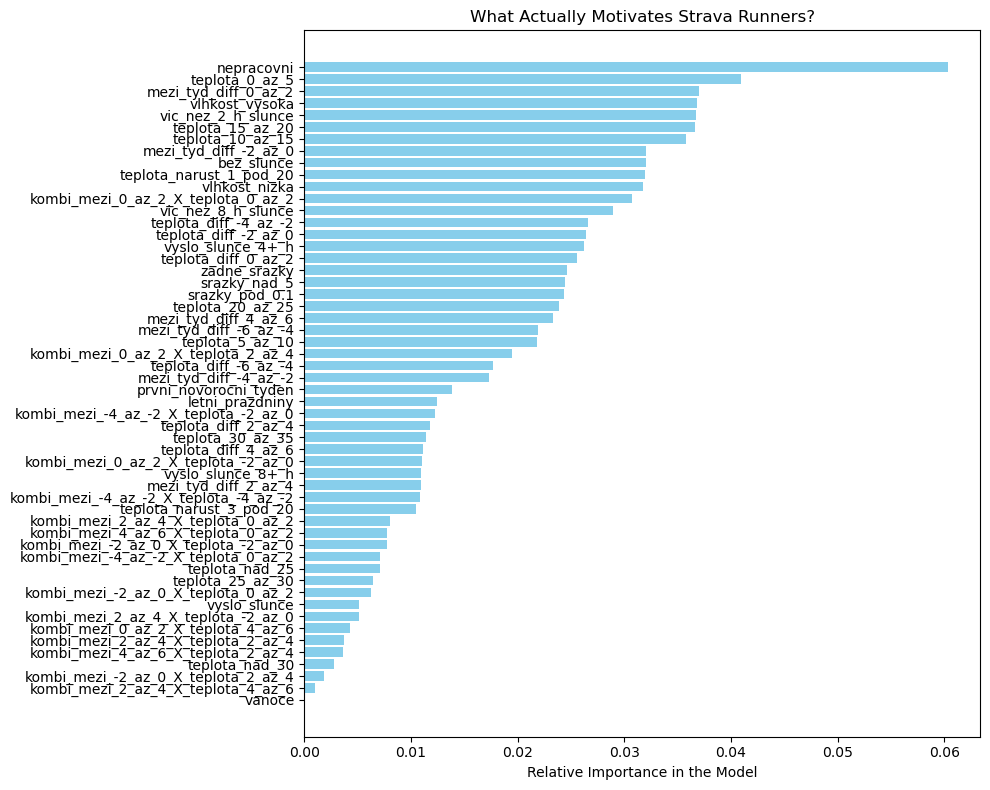

In [26]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title("What Actually Motivates Strava Runners?")
plt.xlabel("Relative Importance in the Model")
plt.tight_layout()
plt.show()

In [27]:
intervals = [(x-2,x) for x in range(-6,36) if x % 2 == 0]
intervals

[(-8, -6),
 (-6, -4),
 (-4, -2),
 (-2, 0),
 (0, 2),
 (2, 4),
 (4, 6),
 (6, 8),
 (8, 10),
 (10, 12),
 (12, 14),
 (14, 16),
 (16, 18),
 (18, 20),
 (20, 22),
 (22, 24),
 (24, 26),
 (26, 28),
 (28, 30),
 (30, 32),
 (32, 34)]

In [28]:
# 2. Dynamically generate the 36 combination expressions
interaction_exprs = []
for low, high in intervals:

    nazev = f'param_teplota_mezi_{low}_a_{high}'
    print(nazev)
    
    expr = pl.when(
        pl.col("teplota").is_between(low, high, closed='both')
    ).then(
        pl.lit(1)
    ).otherwise(
        pl.lit(0)
    ).alias(
        nazev
    )

    interaction_exprs.append(expr)
    
    for low_2, high_2 in intervals:
        
        # Create the column name dynamically
        col_name = f"kombi_mezi_{low}_az_{high}_X_teplota_{low_2}_az_{high_2}"
        print(col_name)
        
        # Build the condition (Mezitydenni AND Teplota)
        expr = pl.when(
            pl.col("teplota").is_between(low, high, closed=m_closed) &
            pl.col("teplota_shift").is_between(low, high, closed=t_closed)
        ).then(pl.lit(1)).otherwise(pl.lit(0)).alias(f'param_{col_name}')
    
        interaction_exprs.append(expr)

df_model_tyden = dfp.with_columns(
    pl.when(pl.col("effort_diff") > 1000)
    .then(pl.lit(800))
    .otherwise(pl.col('effort_diff'))
    .alias('effort_diff')
).group_by_dynamic(
    index_column="DT",every="1w"
).agg(
    pl.col("effort_diff").sum(),
    pl.col("srazky").mean(),
    pl.col("teplota").mean(),
    pl.col("vlhkost").mean(),
    pl.col("slunecni_svit").mean(),
).with_columns(
    (pl.col(x).shift(1) / pl.col(x)).alias(f'{x}_shift') for x in ['effort_diff','srazky','teplota','vlhkost','slunecni_svit']
).with_columns(
    *interaction_exprs
).drop_nulls(
)

df_model_tyden.tail(10)

param_teplota_mezi_-8_a_-6
kombi_mezi_-8_az_-6_X_teplota_-8_az_-6
kombi_mezi_-8_az_-6_X_teplota_-6_az_-4
kombi_mezi_-8_az_-6_X_teplota_-4_az_-2
kombi_mezi_-8_az_-6_X_teplota_-2_az_0
kombi_mezi_-8_az_-6_X_teplota_0_az_2
kombi_mezi_-8_az_-6_X_teplota_2_az_4
kombi_mezi_-8_az_-6_X_teplota_4_az_6
kombi_mezi_-8_az_-6_X_teplota_6_az_8
kombi_mezi_-8_az_-6_X_teplota_8_az_10
kombi_mezi_-8_az_-6_X_teplota_10_az_12
kombi_mezi_-8_az_-6_X_teplota_12_az_14
kombi_mezi_-8_az_-6_X_teplota_14_az_16
kombi_mezi_-8_az_-6_X_teplota_16_az_18
kombi_mezi_-8_az_-6_X_teplota_18_az_20
kombi_mezi_-8_az_-6_X_teplota_20_az_22
kombi_mezi_-8_az_-6_X_teplota_22_az_24
kombi_mezi_-8_az_-6_X_teplota_24_az_26
kombi_mezi_-8_az_-6_X_teplota_26_az_28
kombi_mezi_-8_az_-6_X_teplota_28_az_30
kombi_mezi_-8_az_-6_X_teplota_30_az_32
kombi_mezi_-8_az_-6_X_teplota_32_az_34
param_teplota_mezi_-6_a_-4
kombi_mezi_-6_az_-4_X_teplota_-8_az_-6
kombi_mezi_-6_az_-4_X_teplota_-6_az_-4
kombi_mezi_-6_az_-4_X_teplota_-4_az_-2
kombi_mezi_-6_az_-4_

DT,effort_diff,srazky,teplota,vlhkost,slunecni_svit,effort_diff_shift,srazky_shift,teplota_shift,vlhkost_shift,slunecni_svit_shift,param_teplota_mezi_-8_a_-6,param_kombi_mezi_-8_az_-6_X_teplota_-8_az_-6,param_kombi_mezi_-8_az_-6_X_teplota_-6_az_-4,param_kombi_mezi_-8_az_-6_X_teplota_-4_az_-2,param_kombi_mezi_-8_az_-6_X_teplota_-2_az_0,param_kombi_mezi_-8_az_-6_X_teplota_0_az_2,param_kombi_mezi_-8_az_-6_X_teplota_2_az_4,param_kombi_mezi_-8_az_-6_X_teplota_4_az_6,param_kombi_mezi_-8_az_-6_X_teplota_6_az_8,param_kombi_mezi_-8_az_-6_X_teplota_8_az_10,param_kombi_mezi_-8_az_-6_X_teplota_10_az_12,param_kombi_mezi_-8_az_-6_X_teplota_12_az_14,param_kombi_mezi_-8_az_-6_X_teplota_14_az_16,param_kombi_mezi_-8_az_-6_X_teplota_16_az_18,param_kombi_mezi_-8_az_-6_X_teplota_18_az_20,param_kombi_mezi_-8_az_-6_X_teplota_20_az_22,param_kombi_mezi_-8_az_-6_X_teplota_22_az_24,param_kombi_mezi_-8_az_-6_X_teplota_24_az_26,param_kombi_mezi_-8_az_-6_X_teplota_26_az_28,param_kombi_mezi_-8_az_-6_X_teplota_28_az_30,param_kombi_mezi_-8_az_-6_X_teplota_30_az_32,param_kombi_mezi_-8_az_-6_X_teplota_32_az_34,param_teplota_mezi_-6_a_-4,param_kombi_mezi_-6_az_-4_X_teplota_-8_az_-6,param_kombi_mezi_-6_az_-4_X_teplota_-6_az_-4,param_kombi_mezi_-6_az_-4_X_teplota_-4_az_-2,…,param_kombi_mezi_30_az_32_X_teplota_4_az_6,param_kombi_mezi_30_az_32_X_teplota_6_az_8,param_kombi_mezi_30_az_32_X_teplota_8_az_10,param_kombi_mezi_30_az_32_X_teplota_10_az_12,param_kombi_mezi_30_az_32_X_teplota_12_az_14,param_kombi_mezi_30_az_32_X_teplota_14_az_16,param_kombi_mezi_30_az_32_X_teplota_16_az_18,param_kombi_mezi_30_az_32_X_teplota_18_az_20,param_kombi_mezi_30_az_32_X_teplota_20_az_22,param_kombi_mezi_30_az_32_X_teplota_22_az_24,param_kombi_mezi_30_az_32_X_teplota_24_az_26,param_kombi_mezi_30_az_32_X_teplota_26_az_28,param_kombi_mezi_30_az_32_X_teplota_28_az_30,param_kombi_mezi_30_az_32_X_teplota_30_az_32,param_kombi_mezi_30_az_32_X_teplota_32_az_34,param_teplota_mezi_32_a_34,param_kombi_mezi_32_az_34_X_teplota_-8_az_-6,param_kombi_mezi_32_az_34_X_teplota_-6_az_-4,param_kombi_mezi_32_az_34_X_teplota_-4_az_-2,param_kombi_mezi_32_az_34_X_teplota_-2_az_0,param_kombi_mezi_32_az_34_X_teplota_0_az_2,param_kombi_mezi_32_az_34_X_teplota_2_az_4,param_kombi_mezi_32_az_34_X_teplota_4_az_6,param_kombi_mezi_32_az_34_X_teplota_6_az_8,param_kombi_mezi_32_az_34_X_teplota_8_az_10,param_kombi_mezi_32_az_34_X_teplota_10_az_12,param_kombi_mezi_32_az_34_X_teplota_12_az_14,param_kombi_mezi_32_az_34_X_teplota_14_az_16,param_kombi_mezi_32_az_34_X_teplota_16_az_18,param_kombi_mezi_32_az_34_X_teplota_18_az_20,param_kombi_mezi_32_az_34_X_teplota_20_az_22,param_kombi_mezi_32_az_34_X_teplota_22_az_24,param_kombi_mezi_32_az_34_X_teplota_24_az_26,param_kombi_mezi_32_az_34_X_teplota_26_az_28,param_kombi_mezi_32_az_34_X_teplota_28_az_30,param_kombi_mezi_32_az_34_X_teplota_30_az_32,param_kombi_mezi_32_az_34_X_teplota_32_az_34
date,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
2025-10-27,1938,2.985714,13.028571,80.714286,4.014286,0.765738,0.357257,1.054094,0.947788,0.651839,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025-11-03,2117,1.085714,11.371429,89.142857,4.542857,0.915446,2.75,1.145729,0.905449,0.883648,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025-11-10,1341,0.12,10.7,90.2,3.5,1.578673,9.047619,1.06275,0.98828,1.297959,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025-11-17,2519,0.471429,3.828571,79.285714,3.357143,0.532354,0.254545,2.794776,1.137658,1.042553,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,

In [29]:
vyhodit_tyden = df_model_tyden.select(pl.all()).sum().unpivot().filter(pl.col("value") < 1).select(pl.col("variable")).to_series().to_list()
vyhodit_tyden.append('DT')

In [30]:
features = [x for x in df_model_tyden.columns if "param" in x or 'kombi' in x]
for v in vyhodit_tyden:
    try:
        features.remove(v)
    except:
        pass

X = df_model_tyden[features].to_pandas()
y = df_model_tyden['effort_diff'].to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

rf_model_tyden = RandomForestRegressor(
    n_estimators=1000,       # More trees
    max_depth=None,         # Unlimited depth
    min_samples_split=2,    # Split aggressively
    min_samples_leaf=1,     # Fine-grained leaves
    max_features=0.8,       # Consider 80% of features at each split
    n_jobs=-1,              # Use all CPU cores to handle the extra load
    random_state=42
)
rf_model_tyden.fit(X_train, y_train)

predictions = rf_model_tyden.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} efforts")

importances = rf_model_tyden.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

feature_importance_df.sort_values(by='Importance', ascending=False)

Mean Absolute Error: 377.51 efforts


,Feature,Importance
0,param_teplota_mezi_2_a_4,0.219369
26,param_teplota_mezi_12_a_14,0.213428
22,param_teplota_mezi_4_a_6,0.173583
30,param_teplota_mezi_22_a_24,0.106169
27,param_teplota_mezi_14_a_16,0.089866
29,param_teplota_mezi_20_a_22,0.067425
31,param_teplota_mezi_24_a_26,0.025284
33,param_teplota_mezi_28_a_30,0.021502
25,param_teplota_mezi_10_a_12,0.015801
32,param_teplota_mezi_26_a_28,0.014331


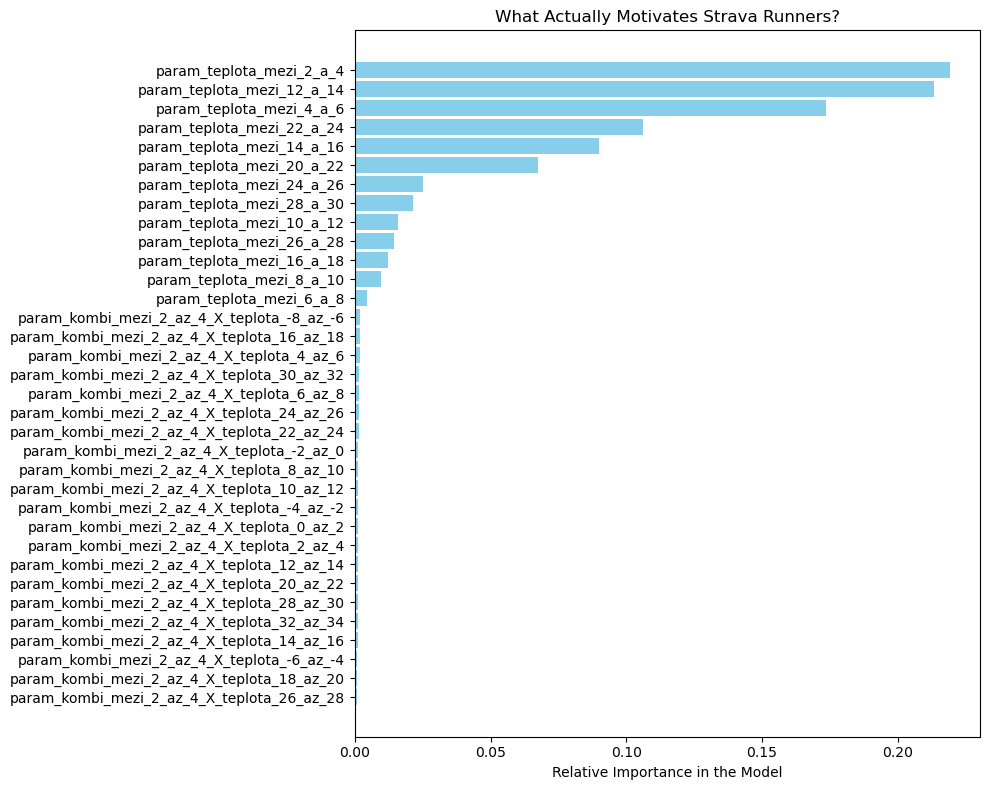

In [31]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title("What Actually Motivates Strava Runners?")
plt.xlabel("Relative Importance in the Model")
plt.tight_layout()
plt.show()

In [32]:
import shap

C:\Users\micha\anaconda3\envs\ml_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
explainer = shap.TreeExplainer(rf_model)

In [ ]:
shap_values = explainer.shap_values(X_train)

In [ ]:
shap.summary_plot(shap_values, X_train)

In [ ]:
dfp.columns

In [ ]:
# Create a clean dataframe for math (drop NaNs so the calculator doesn't freak out)
df_corr = dfp.select(pl.col(
 'effort_diff',
 'srazky',
 'slunecni_svit',
 'teplota',
 'vlhkost')).to_pandas()

# 2. Calculate the Pearson Correlation Matrix
# This calculates how every single column moves in relation to every other column
correlation_matrix = df_corr.corr(method='pearson')

# 3. Isolate just the target variable (effort_diff)
# We don't need the whole massive grid, just how things relate to the runner count
target_corr = correlation_matrix['effort_diff'].drop('effort_diff')

# Sort them from strongest Motivator to strongest Barrier
target_corr_sorted = target_corr.sort_values(ascending=False)

# 4. Print the raw numbers for the stat nerds
print("--- STRONGEST MOTIVATORS (+1.0) ---")
print(target_corr_sorted.head(5))
print("\n--- STRONGEST BARRIERS (-1.0) ---")
print(target_corr_sorted.tail(5))

In [ ]:
cols_to_check = features + ['effort_diff'] 

# Create a clean dataframe for math (drop NaNs so the calculator doesn't freak out)
df_corr = df_model[cols_to_check].to_pandas().dropna()

# 2. Calculate the Pearson Correlation Matrix
# This calculates how every single column moves in relation to every other column
correlation_matrix = df_corr.corr(method='pearson')

# 3. Isolate just the target variable (effort_diff)
# We don't need the whole massive grid, just how things relate to the runner count
target_corr = correlation_matrix['effort_diff'].drop('effort_diff')

# Sort them from strongest Motivator to strongest Barrier
target_corr_sorted = target_corr.sort_values(ascending=False)

# 4. Print the raw numbers for the stat nerds
print("--- STRONGEST MOTIVATORS (+1.0) ---")
print(target_corr_sorted.head(5))
print("\n--- STRONGEST BARRIERS (-1.0) ---")
print(target_corr_sorted.tail(5))

In [ ]:
import seaborn as sns

In [ ]:
plt.figure(figsize=(10, 8))

# Create a color map: Green for positive (Motivators), Red for negative (Barriers)
colors = ['#ff9999' if x < 0 else '#99ff99' for x in target_corr_sorted.values]

sns.barplot(x=target_corr_sorted.values, y=target_corr_sorted.index, palette=colors)

plt.title("Correlation with Strava Efforts: Motivators vs. Barriers")
plt.xlabel("Correlation Coefficient (Pearson)")
plt.ylabel("Weather & Psychological Features")
plt.axvline(x=0, color='black', linestyle='--') # The "Neutral" line
plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame(target_corr_sorted.tail(4))

In [ ]:
korelace_graf = pl.concat(
    [
        pl.from_pandas(pd.DataFrame(target_corr_sorted.head(4)).reset_index()),
        pl.from_pandas(pd.DataFrame(target_corr_sorted.tail(4)).reset_index())   
    ]
).rename(
    {'effort_diff':'korelace s počtem běhů'}
).with_columns(
    pl.col("index").str.replace_many(
        [
            'teplota_15_az_20','nepracovni','mezi_tyd_diff_-6_az_-4',"teplota_20_az_25","srazky_nad_5","vanoce","bez_slunce","teplota_0_az_5"
        ],
        [
            'denní teplota 15 až 20 °C','nepracovní den','mezitýdenní ochlazení o 4 až 6 °C','denní teplota 20 až 25 °C','srážky nad 5 mm','Vánoce','den bez slunce','denní teplota 0 až 5 °C'
        ]
    )
)

korelace_graf.write_json('data/korelace_behani.json')

korelace_graf

In [ ]:
raise SystemExit("Stop right there!")

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
PartialDependenceDisplay.from_estimator(
    rf_model, 
    X_train, 
    features,
    ax=ax,
    grid_resolution=50 # Makes the lines smoother
)

plt.suptitle("At what point do Motivations become Barriers?")
plt.tight_layout()
plt.show()

In [ ]:
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

In [ ]:
# 1. Initialize the EBM
# It's an additive model, meaning it looks at the isolated effect of each feature
ebm = ExplainableBoostingRegressor(random_state=42, n_jobs=1)

# 2. Train the model
print("Training the Glass Box...")
ebm.fit(X_train, y_train)

# 3. Quick Evaluation
predictions_ebm = ebm.predict(X_test)
from sklearn.metrics import mean_absolute_error
mae_ebm = mean_absolute_error(y_test, predictions_ebm)
print(f"EBM Mean Absolute Error: {mae_ebm:.2f} efforts")

# 4. The Magic: Global Explanations (The "Rulebook")
ebm_global = ebm.explain_global(name='Strava Runner Psychology (Overall)')

# 5. Local Explanations (The "Specific Day" Breakdown)
# Let's look at the first 5 days in your test set to see exactly why people ran
ebm_local = ebm.explain_local(X_test[:5], y_test[:5], name='Specific Days Breakdown')

# 6. Open the Interactive Dashboard
# If you are in a Jupyter Notebook, this will render directly below the cell.
# If you are in a script, it will pop open a tab in your web browser.
show([ebm_global, ebm_local])